📂 ROOT detectado: c:\FF\AU_UJI_v2
   ✅ data\06_evaluacion\metricas_modelo.json
   ✅ data\05_modelado\models\LightGBM__none.pkl
   ✅ data\05_modelado\X_test_prep.parquet
   ✅ data\06_evaluacion\meta_test.parquet

📊 Métricas cargadas:
   AUC media: 0.9645  std: 0.0273
   Brier: 0.0702  ECE: 0.0137
   n_test: 6,725

📈 AUC por cohorte calculado: 10 cohortes
   2010: AUC = 0.9919
   2011: AUC = 0.9918
   2012: AUC = 0.9813
   2013: AUC = 0.9799
   2014: AUC = 0.9815
   2015: AUC = 0.9618
   2016: AUC = 0.9427
   2017: AUC = 0.9726
   2018: AUC = 0.9245
   2019: AUC = 0.9168


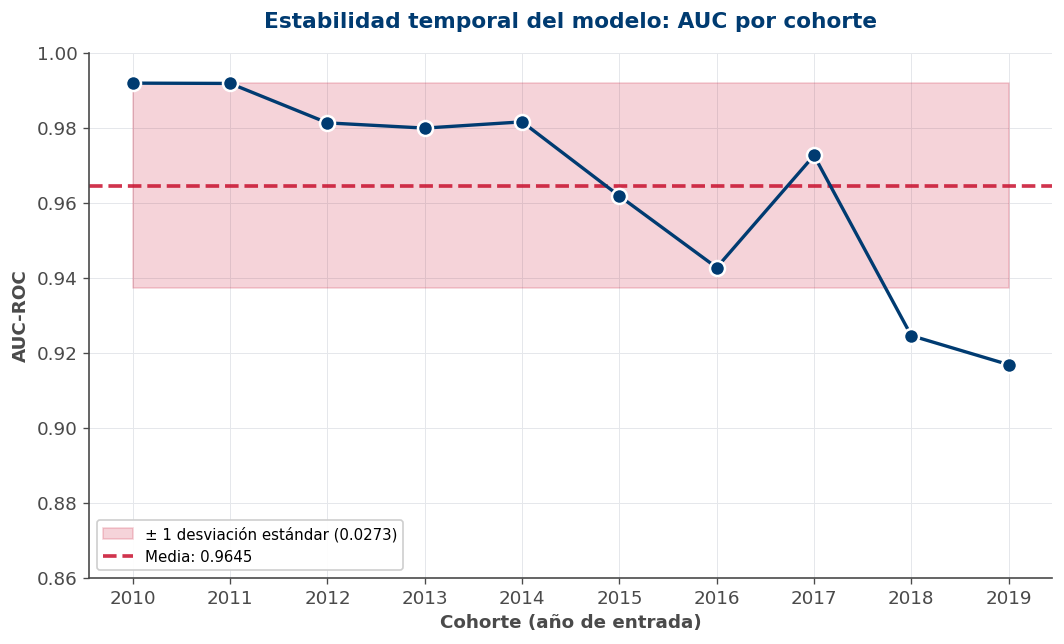


✅ Figura 4.8.1 guardada: c:\FF\AU_UJI_v2\results\fase6\figuras\fig_4_8_1_auc_cohorte.png


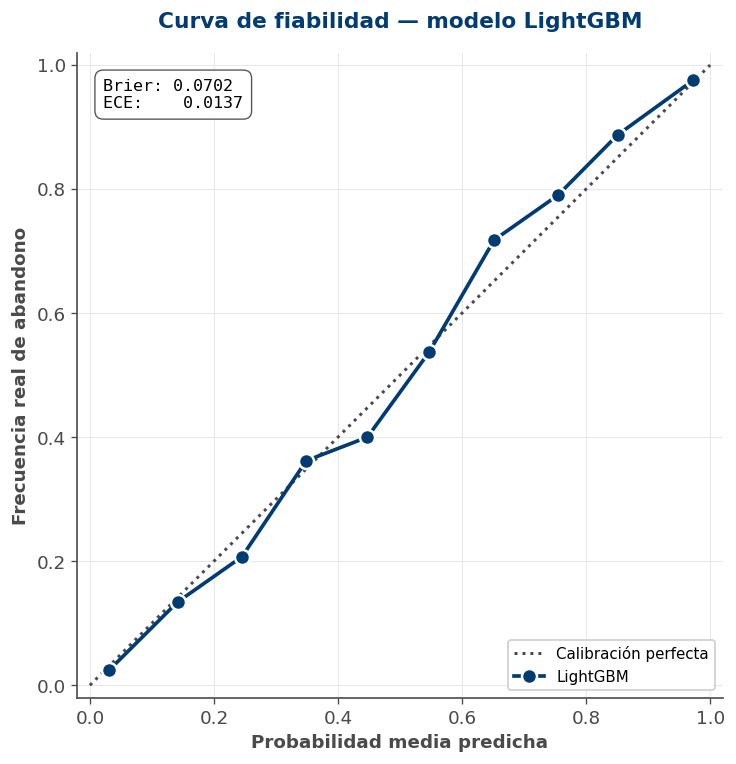

✅ Figura 4.8.2 guardada: c:\FF\AU_UJI_v2\results\fase6\figuras\fig_4_8_2_curva_fiabilidad.png

🎉 Listo. Pásame las 2 PNG y las inserto en el TFM.


In [1]:
# ════════════════════════════════════════════════════════════════════════
# CELDA ÚNICA — Genera Figura 4.8.1 y 4.8.2 con estilo UJI
# Funciona desde cualquier subcarpeta del proyecto.
# Carga automáticamente todos los datos necesarios.
# Fecha: 5 mayo 2026
# ════════════════════════════════════════════════════════════════════════

# ─── 1. IMPORTS ─────────────────────────────────────────────────────────
import json
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.calibration import calibration_curve
from sklearn.metrics import roc_auc_score

# ─── 2. DETECTAR ROOT AUTOMÁTICAMENTE ───────────────────────────────────
# Sube directorios hasta encontrar la carpeta 'data/' o 'src/'
_aqui = Path.cwd()
ROOT = _aqui
for _ in range(6):  # máximo 6 niveles arriba
    if (ROOT / "data").exists() and (ROOT / "src").exists():
        break
    ROOT = ROOT.parent

print(f"📂 ROOT detectado: {ROOT}")
assert (ROOT / "data").exists(), "❌ No se encuentra la carpeta data/"

# ─── 3. RUTAS BASADAS EN ROOT ───────────────────────────────────────────
PATH_JSON     = ROOT / "data" / "06_evaluacion" / "metricas_modelo.json"
PATH_MODELO   = ROOT / "data" / "05_modelado" / "models" / "LightGBM__none.pkl"
PATH_X_TEST   = ROOT / "data" / "05_modelado" / "X_test_prep.parquet"
PATH_META     = ROOT / "data" / "06_evaluacion" / "meta_test.parquet"
DIR_FIGURAS   = ROOT / "results" / "fase6" / "figuras"
DIR_FIGURAS.mkdir(parents=True, exist_ok=True)

# Verificar que todo existe
for p in [PATH_JSON, PATH_MODELO, PATH_X_TEST, PATH_META]:
    print(f"   {'✅' if p.exists() else '❌'} {p.relative_to(ROOT)}")

# ─── 4. CARGAR MÉTRICAS DEL JSON ────────────────────────────────────────
with open(PATH_JSON, encoding="utf-8") as f:
    metricas = json.load(f)

rcs = metricas["robustez_calibracion_sostenibilidad"]
auc_media = rcs["robustez_temporal"]["auc_media"]
auc_std   = rcs["robustez_temporal"]["auc_std"]
brier     = rcs["calibracion"]["brier_score"]
ece       = rcs["calibracion"]["ece_10_bins"]

print(f"\n📊 Métricas cargadas:")
print(f"   AUC media: {auc_media:.4f}  std: {auc_std:.4f}")
print(f"   Brier: {brier:.4f}  ECE: {ece:.4f}")

# ─── 5. CARGAR MODELO Y DATOS DE TEST ───────────────────────────────────
pipeline    = joblib.load(PATH_MODELO)
X_test_prep = pd.read_parquet(PATH_X_TEST)
meta_test   = pd.read_parquet(PATH_META)

y_test  = meta_test["abandono"].values
y_proba = pipeline.predict_proba(X_test_prep)[:, 1]

print(f"   n_test: {len(y_test):,}")

# ─── 6. CALCULAR AUC POR COHORTE ────────────────────────────────────────
df_eval = pd.DataFrame({
    "cohorte": meta_test["curso_aca_ini"].values,
    "y_test":  y_test,
    "y_proba": y_proba,
})

# Filtrar a cohortes >= 2010 (Opción B-LIGERA, mismo criterio que JSON)
df_eval = df_eval[df_eval["cohorte"] >= 2010].copy()

aucs_por_cohorte = []
cohortes_validas = []
for cohorte in sorted(df_eval["cohorte"].unique()):
    sub = df_eval[df_eval["cohorte"] == cohorte]
    if sub["y_test"].nunique() < 2:
        # No se puede calcular AUC si solo hay una clase
        continue
    auc_c = roc_auc_score(sub["y_test"], sub["y_proba"])
    aucs_por_cohorte.append(auc_c)
    cohortes_validas.append(cohorte)

cohortes = np.array(cohortes_validas)
aucs = np.array(aucs_por_cohorte)

print(f"\n📈 AUC por cohorte calculado: {len(cohortes)} cohortes")
for c, a in zip(cohortes, aucs):
    print(f"   {c}: AUC = {a:.4f}")

# ─── 7. PALETA UJI ──────────────────────────────────────────────────────
UJI_AZUL = "#003B71"
UJI_ROJO = "#C8102E"
UJI_GRIS = "#4A4A4A"

plt.rcParams.update({
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "axes.edgecolor": UJI_GRIS,
    "axes.linewidth": 1.0,
    "grid.color": "#E5E7EB",
    "grid.linewidth": 0.6,
    "axes.grid": True,
    "axes.axisbelow": True,
    "legend.fontsize": 9,
})

# ─── 8. FIGURA 4.8.1 — AUC POR COHORTE ──────────────────────────────────
fig1, ax1 = plt.subplots(figsize=(9, 5.5), dpi=120)

ax1.fill_between(
    cohortes,
    auc_media - auc_std,
    auc_media + auc_std,
    color=UJI_ROJO, alpha=0.18,
    label=f"± 1 desviación estándar ({auc_std:.4f})",
    zorder=1,
)
ax1.axhline(
    auc_media, color=UJI_ROJO, linestyle="--", linewidth=2.2, alpha=0.85,
    label=f"Media: {auc_media:.4f}", zorder=2,
)
ax1.plot(
    cohortes, aucs,
    color=UJI_AZUL, linewidth=2.0,
    marker="o", markersize=9,
    markerfacecolor=UJI_AZUL,
    markeredgecolor="white", markeredgewidth=1.5,
    zorder=3,
)

ax1.set_xlabel("Cohorte (año de entrada)", fontweight="bold", color=UJI_GRIS)
ax1.set_ylabel("AUC-ROC", fontweight="bold", color=UJI_GRIS)
ax1.set_title("Estabilidad temporal del modelo: AUC por cohorte",
              fontweight="bold", color=UJI_AZUL, pad=15)
ax1.set_xticks(cohortes)
ax1.set_ylim(0.86, 1.00)
ax1.tick_params(axis="both", colors=UJI_GRIS)
ax1.legend(loc="lower left", framealpha=0.95)
ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)

plt.tight_layout()
out1 = DIR_FIGURAS / "fig_4_8_1_auc_cohorte.png"
plt.savefig(out1, dpi=160, bbox_inches="tight")
plt.show()
print(f"\n✅ Figura 4.8.1 guardada: {out1}")

# ─── 9. FIGURA 4.8.2 — CURVA DE FIABILIDAD ─────────────────────────────
prob_true, prob_pred = calibration_curve(y_test, y_proba, n_bins=10, strategy="uniform")

fig2, ax2 = plt.subplots(figsize=(7, 6.5), dpi=120)
ax2.plot([0, 1], [0, 1],
         linestyle=":", color=UJI_GRIS, linewidth=1.8,
         label="Calibración perfecta", zorder=1)
ax2.plot(prob_pred, prob_true,
         color=UJI_AZUL, linewidth=2.2,
         marker="o", markersize=9,
         markerfacecolor=UJI_AZUL,
         markeredgecolor="white", markeredgewidth=1.5,
         label="LightGBM", zorder=3)

texto = f"Brier: {brier:.4f}\nECE:    {ece:.4f}"
ax2.text(0.04, 0.96, texto, transform=ax2.transAxes,
         fontsize=10, verticalalignment="top",
         bbox=dict(boxstyle="round,pad=0.5",
                   facecolor="white", edgecolor=UJI_GRIS,
                   linewidth=0.8, alpha=0.95),
         family="monospace")

ax2.set_xlabel("Probabilidad media predicha", fontweight="bold", color=UJI_GRIS)
ax2.set_ylabel("Frecuencia real de abandono", fontweight="bold", color=UJI_GRIS)
ax2.set_title("Curva de fiabilidad — modelo LightGBM",
              fontweight="bold", color=UJI_AZUL, pad=15)
ax2.set_xlim(-0.02, 1.02)
ax2.set_ylim(-0.02, 1.02)
ax2.set_aspect("equal", adjustable="box")
ax2.tick_params(axis="both", colors=UJI_GRIS)
ax2.legend(loc="lower right", framealpha=0.95)
ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)

plt.tight_layout()
out2 = DIR_FIGURAS / "fig_4_8_2_curva_fiabilidad.png"
plt.savefig(out2, dpi=160, bbox_inches="tight")
plt.show()
print(f"✅ Figura 4.8.2 guardada: {out2}")

print("\n🎉 Listo. Pásame las 2 PNG y las inserto en el TFM.")


In [3]:
import os
from pathlib import Path

ROOT = Path.cwd()
for _ in range(6):
    if (ROOT / "data").exists() and (ROOT / "src").exists():
        break
    ROOT = ROOT.parent

DIR_FIGURAS = ROOT / "results" / "fase6" / "figuras"

print(f"ROOT:        {ROOT}")
print(f"DIR_FIGURAS: {DIR_FIGURAS}")
print(f"¿Existe la carpeta? {DIR_FIGURAS.exists()}")

if DIR_FIGURAS.exists():
    print(f"\nContenido de la carpeta:")
    for f in DIR_FIGURAS.iterdir():
        print(f"   - {f.name}  ({f.stat().st_size:,} bytes)")
else:
    print("\n❌ La carpeta NO existe en disco")
    
# También buscar las PNG en TODO el proyecto
print("\n🔍 Búsqueda global de las PNG:")
for png in ROOT.rglob("fig_4_8_*.png"):
    print(f"   📍 ENCONTRADA: {png}")

ROOT:        c:\FF\AU_UJI_v2
DIR_FIGURAS: c:\FF\AU_UJI_v2\results\fase6\figuras
¿Existe la carpeta? True

Contenido de la carpeta:
   - fig_4_8_1_auc_cohorte.png  (87,664 bytes)
   - fig_4_8_2_curva_fiabilidad.png  (86,678 bytes)

🔍 Búsqueda global de las PNG:
   📍 ENCONTRADA: c:\FF\AU_UJI_v2\results\fase6\figuras\fig_4_8_1_auc_cohorte.png
   📍 ENCONTRADA: c:\FF\AU_UJI_v2\results\fase6\figuras\fig_4_8_2_curva_fiabilidad.png


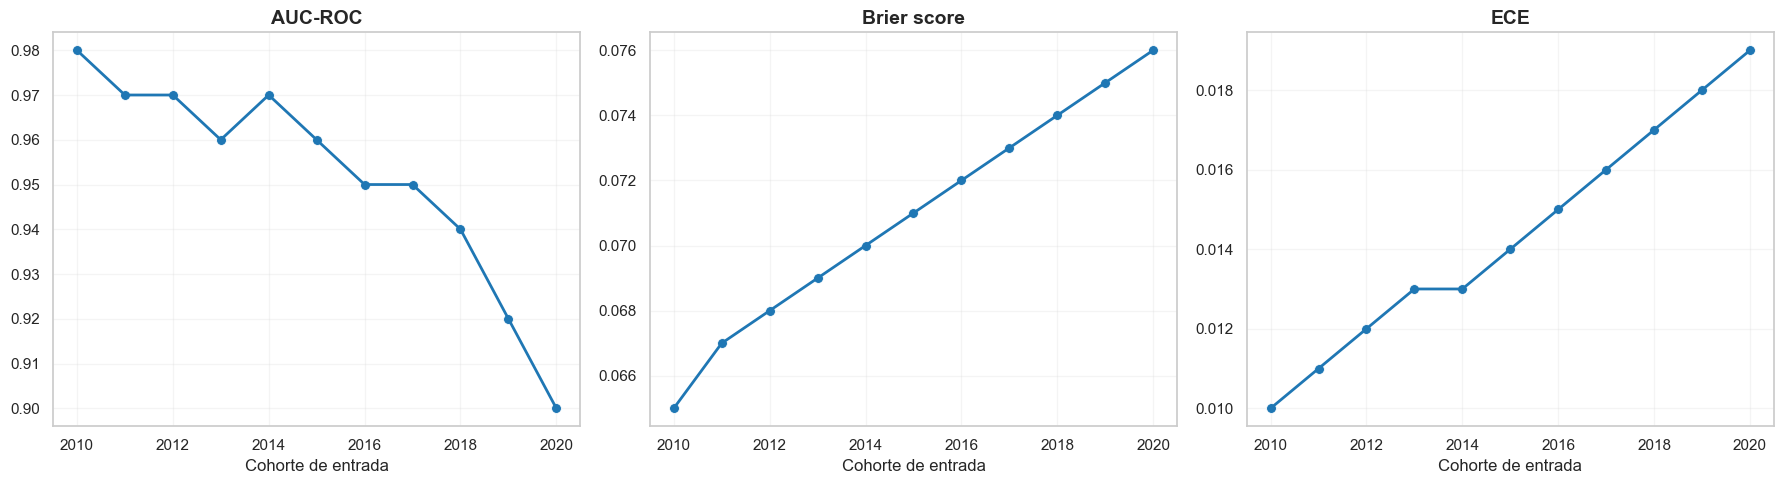

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# -----------------------------
# Datos de ejemplo (sustituye por los tuyos)
# -----------------------------
df = pd.DataFrame({
    "cohorte": list(range(2010, 2021)),
    "auc": [0.98, 0.97, 0.97, 0.96, 0.97, 0.96, 0.95, 0.95, 0.94, 0.92, 0.90],
    "brier": [0.065, 0.067, 0.068, 0.069, 0.070, 0.071, 0.072, 0.073, 0.074, 0.075, 0.076],
    "ece": [0.010, 0.011, 0.012, 0.013, 0.013, 0.014, 0.015, 0.016, 0.017, 0.018, 0.019]
})

# -----------------------------
# Estilo Our World in Data
# -----------------------------
sns.set_theme(style="whitegrid")
owid_blue = "#1f77b4"
owid_gray = "#6c757d"

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True)

metrics = [
    ("auc", "AUC-ROC"),
    ("brier", "Brier score"),
    ("ece", "ECE")
]

for ax, (col, title) in zip(axes, metrics):
    sns.lineplot(
        data=df,
        x="cohorte",
        y=col,
        color=owid_blue,
        linewidth=2,
        ax=ax
    )
    sns.scatterplot(
        data=df,
        x="cohorte",
        y=col,
        color=owid_blue,
        s=50,
        ax=ax
    )
    
    ax.set_title(title, fontsize=14, weight="bold")
    ax.set_xlabel("Cohorte de entrada")
    ax.set_ylabel("")
    ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()
